# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [66]:
# Import library dasar
import numpy as np
import pandas as pd

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import library untuk data splitting
from sklearn.model_selection import train_test_split

# Import library untuk model klasifikasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Import library untuk evaluasi
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, confusion_matrix

# Import library untuk tuning
from sklearn.model_selection import GridSearchCV

# Pengaturan visualisasi
%matplotlib inline
sns.set_style("whitegrid")

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [ ]:
# Memuat dataset
df = pd.read_csv("bank_transaction_segmented_dataset.csv")

# Menampilkan 5 baris pertama
print("5 Baris Pertama Dataset:")
print(df.head())

# Memeriksa informasi dataset
print("\nInformasi Dataset:")
print(df.info())

5 Baris Pertama Dataset:
   TransactionID  AccountID  TransactionAmount  Location  DeviceID  \
0      -1.731361  -0.841708          -1.510833        36  0.137594   
1      -1.729982   1.418890           0.672289        15 -1.451941   
2      -1.728603  -1.595241          -0.538647        23 -0.548682   
3      -1.727224  -1.246384          -0.152595        33 -0.785850   
4      -1.725845   1.111896          -1.517277         1 -0.200498   

   MerchantID  Channel  CustomerAge  CustomerOccupation  TransactionDuration  \
0   -1.189384        0     1.423718                   0            -0.475448   
1    0.085305        0     1.311287                   0             0.446104   
2   -1.396090        2    -1.443277                   3            -0.940661   
3   -1.637248        2    -1.049768                   3            -1.577340   
4    1.428896        2    -1.049768                   3             1.122718   

   ...       IP1       IP2       IP3       IP4  TransactionType_Debit  \


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [68]:
# Pemilihan feature yang relevant untuk klasifikasi
features = ['TransactionAmount', 'CustomerAge', 'AccountBalance', 'TransactionDuration', 
            'LoginAttempts', 'TransactionType_Debit', 'IP1', 'IP2', 'IP3', 'IP4']
X = df[features]


In [ ]:
# Target adalah Cluster, atau label yang didapat dari clustering setelah
# feature selection
y = df['Cluster']  

In [70]:
# Scaling fitur menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data dengan test size 20% dan stratify berdasarkan label
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [71]:
# Model Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Model KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

Evaluasi Random Forest:
Akurasi: 0.9980
Precision: 0.9960
Recall: 0.9980
F1-Score: 0.9970

Evaluasi KNN:
Akurasi: 0.9980
Precision: 0.9960
Recall: 0.9980
F1-Score: 0.9970


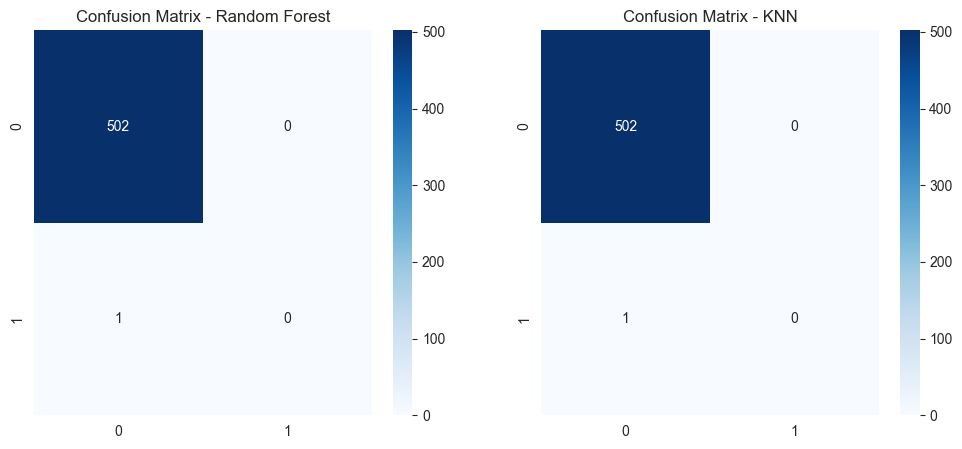

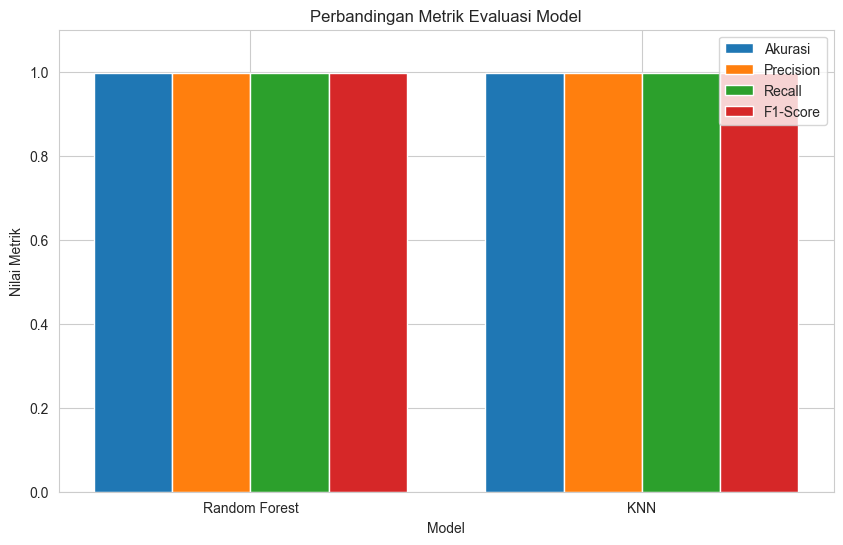

In [72]:
# Prediksi 
rf_pred = rf_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

# Evaluasi Random Forest
print("Evaluasi Random Forest:")
print(f"Akurasi: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_pred, average='weighted', zero_division=0):.4f}")

# Evaluasi KNN
print("\nEvaluasi KNN:")
print(f"Akurasi: {accuracy_score(y_test, knn_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, knn_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, knn_pred, average='weighted', zero_division=0):.4f}")

# Visualisasi confusion matrix
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.show()

# Mengumpulkan metrik evaluasi kedua model
models = ['Random Forest', 'KNN']
accuracy_vals = [accuracy_score(y_test, rf_pred), accuracy_score(y_test, knn_pred)]
precision_vals = [precision_score(y_test, rf_pred, average='weighted', zero_division=0), precision_score(y_test, knn_pred, average='weighted', zero_division=0)]
recall_vals = [recall_score(y_test, rf_pred, average='weighted'), recall_score(y_test, knn_pred, average='weighted')]
f1_vals = [f1_score(y_test, rf_pred, average='weighted', zero_division=0), f1_score(y_test, knn_pred, average='weighted', zero_division=0)]

x = np.arange(len(models))  # Posisi label model
width = 0.2  # Lebar tiap batang

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, accuracy_vals, width, label='Akurasi')
plt.bar(x - 0.5*width, precision_vals, width, label='Precision')
plt.bar(x + 0.5*width, recall_vals, width, label='Recall')
plt.bar(x + 1.5*width, f1_vals, width, label='F1-Score')

plt.xticks(x, models)
plt.xlabel("Model")
plt.ylabel("Nilai Metrik")
plt.title("Perbandingan Metrik Evaluasi Model")
plt.legend()
plt.ylim(0.0, 1.1)
plt.show()

Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [73]:
## Tuning Model dengan GridSearchCV
# Parameter grid untuk Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 4]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=4, scoring='f1_weighted')
rf_grid.fit(X_train, y_train)

# Parameter grid untuk KNN
knn_param_grid = {
    'n_neighbors': [3, 4, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=4, scoring='f1_weighted')
knn_grid.fit(X_train, y_train)

# Model terbaik setelah tuning
best_rf = rf_grid.best_estimator_
best_knn = knn_grid.best_estimator_

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

Evaluasi Random Forest setelah Tuning:
Akurasi: 0.9980
Precision: 0.9960
Recall: 0.9980
F1-Score: 0.9970

Evaluasi KNN setelah Tuning:
Akurasi: 0.9980
Precision: 0.9960
Recall: 0.9980
F1-Score: 0.9970


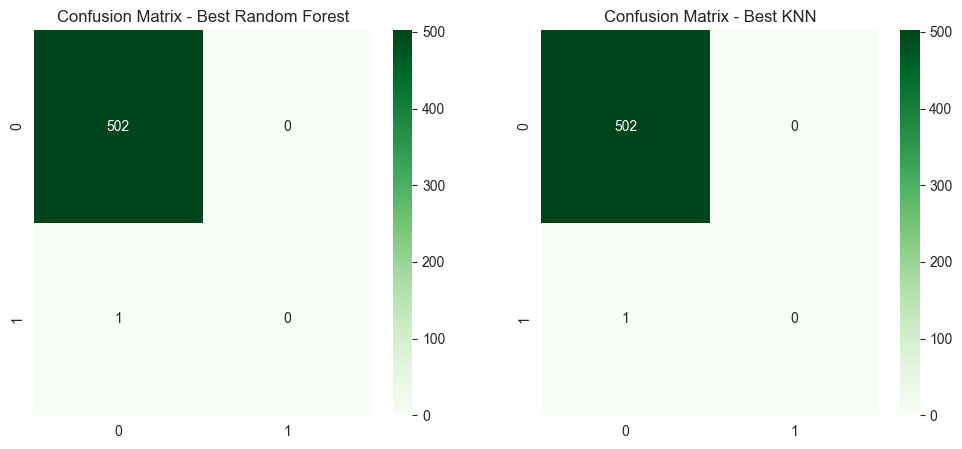

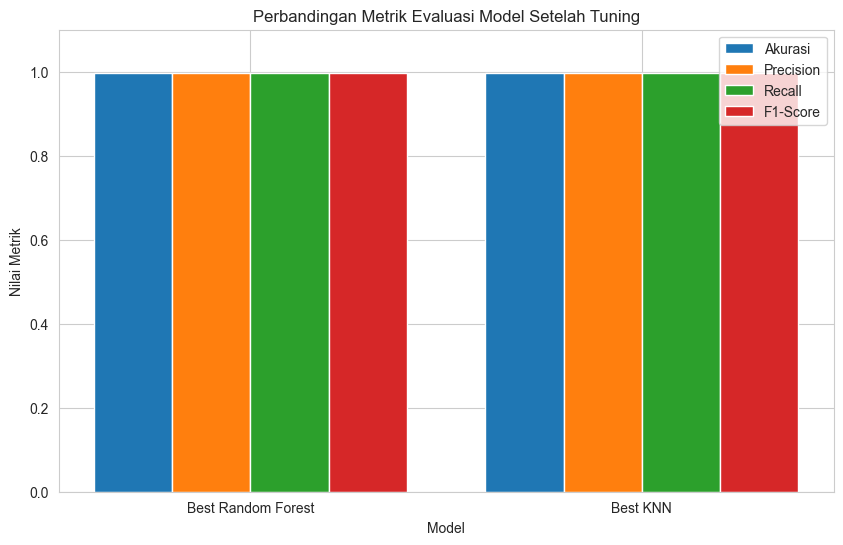

In [74]:
# Prediksi dengan model terbaik
best_rf_pred = best_rf.predict(X_test)
best_knn_pred = best_knn.predict(X_test)

# Evaluasi Random Forest setelah tuning
print("Evaluasi Random Forest setelah Tuning:")
print(f"Akurasi: {accuracy_score(y_test, best_rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_rf_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, best_rf_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, best_rf_pred, average='weighted', zero_division=0):.4f}")

# Evaluasi KNN setelah tuning
print("\nEvaluasi KNN setelah Tuning:")
print(f"Akurasi: {accuracy_score(y_test, best_knn_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_knn_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, best_knn_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, best_knn_pred, average='weighted', zero_division=0):.4f}")

# Visualisasi Confusion Matrix untuk model terbaik setelah tuning
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, best_rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Best Random Forest')
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, best_knn_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Best KNN')
plt.show()

# Mengumpulkan metrik evaluasi kedua model setelah tuning
models = ['Best Random Forest', 'Best KNN']
accuracy_vals = [accuracy_score(y_test, best_rf_pred), accuracy_score(y_test, best_knn_pred)]
precision_vals = [precision_score(y_test, best_rf_pred, average='weighted', zero_division=0),
                  precision_score(y_test, best_knn_pred, average='weighted', zero_division=0)]
recall_vals = [recall_score(y_test, best_rf_pred, average='weighted'),
               recall_score(y_test, best_knn_pred, average='weighted')]
f1_vals = [f1_score(y_test, best_rf_pred, average='weighted', zero_division=0),
           f1_score(y_test, best_knn_pred, average='weighted', zero_division=0)]

x = np.arange(len(models))  # Posisi label model
width = 0.2  # Lebar tiap batang

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, accuracy_vals, width, label='Akurasi')
plt.bar(x - 0.5*width, precision_vals, width, label='Precision')
plt.bar(x + 0.5*width, recall_vals, width, label='Recall')
plt.bar(x + 1.5*width, f1_vals, width, label='F1-Score')

plt.xticks(x, models)
plt.xlabel("Model")
plt.ylabel("Nilai Metrik")
plt.title("Perbandingan Metrik Evaluasi Model Setelah Tuning")
plt.legend()
plt.ylim(0.0, 1.1)
plt.show()


## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.


Perbandingan Performa Model:
----------------------------------------
Random Forest (Sebelum Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------
Random Forest (Setelah Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------
KNN (Sebelum Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------
KNN (Setelah Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------

Analisis Kelemahan Model:
----------------------------------------
Random Forest:
  - Confusion Matrix:
 [[502   0]
 [  1   0]]
  - Precision dan Recall per kelas:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       502
           1       0.00      0.00      0.00         1

    accuracy                           1.00       503
   macro avg       0.50      0.50      0.50       503
weighted avg       1.00      1.00      1.00       503

  - Kemungkinan 

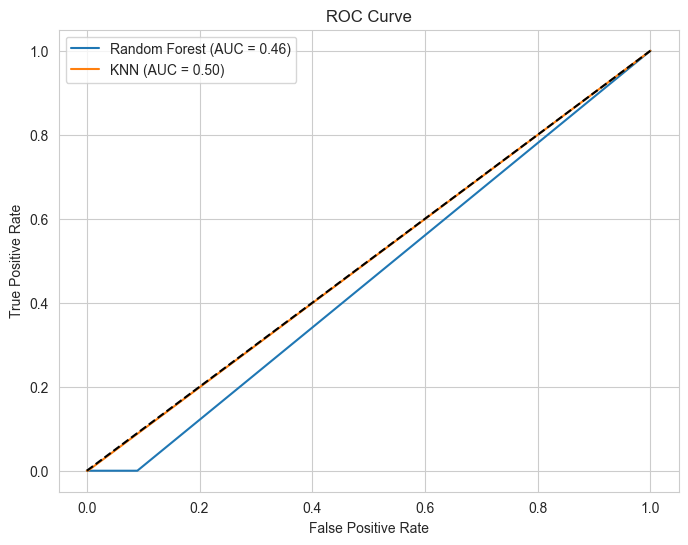

In [75]:
# Fungsi untuk menampilkan perbandingan performa model
def compare_models(models, model_names, X_test, y_test):
    print("\nPerbandingan Performa Model:")
    print("-" * 40)
    for model, name in zip(models, model_names):
        pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average='weighted')
        print(f"{name}:")
        print(f"  Akurasi: {accuracy:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print("-" * 40)

# Daftar model dan nama
models = [rf_model, best_rf, knn_model, best_knn]
model_names = ["Random Forest (Sebelum Tuning)", "Random Forest (Setelah Tuning)", 
               "KNN (Sebelum Tuning)", "KNN (Setelah Tuning)"]

# Panggil fungsi perbandingan
compare_models(models, model_names, X_test, y_test)

# Analisis Kelemahan Model
print("\nAnalisis Kelemahan Model:")
print("-" * 40)

# Analisis untuk Random Forest
best_rf_pred = best_rf.predict(X_test)
print("Random Forest:")
rf_cm = confusion_matrix(y_test, best_rf_pred)
print("  - Confusion Matrix:\n", rf_cm)
print("  - Precision dan Recall per kelas:\n", classification_report(y_test, best_rf_pred, zero_division=0))
print("  - Kemungkinan overfitting jika akurasi training jauh lebih tinggi dari testing.")
print("-" * 40)

# Analisis untuk KNN
best_knn_pred = best_knn.predict(X_test)
print("KNN:")
knn_cm = confusion_matrix(y_test, best_knn_pred)
print("  - Confusion Matrix:\n", knn_cm)
print("  - Precision dan Recall per kelas:\n", classification_report(y_test, best_knn_pred, zero_division=0))
print("  - Sensitif terhadap skala data dan outliers.")
print("-" * 40)

# Rekomendasi untuk Peningkatan
print("\nRekomendasi untuk Peningkatan:")
print("-" * 40)
print("1. Gunakan Random Forest sebagai model utama karena performa yang lebih baik.")
print("2. Kumpulkan lebih banyak data untuk kelas minoritas untuk mengurangi bias.")
print("3. Eksperimen dengan algoritma lain seperti SVM atau Gradient Boosting.")
print("4. Lakukan feature engineering tambahan, misalnya dengan menggabungkan fitur baru.")
print("5. Terapkan teknik oversampling (misalnya SMOTE) untuk menangani ketidakseimbangan kelas.")
print("-" * 40)

# Visualisasi ROC Curve (jika klasifikasi biner)
if len(np.unique(y_test)) == 2:
    plt.figure(figsize=(8, 6))
    for model, name in zip([best_rf, best_knn], ["Random Forest", "KNN"]):
        prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC Curve tidak ditampilkan karena klasifikasi multiclass.")

# Analisis Hasil Evaluasi Model Klasifikasi

## 1. Ringkasan Hasil Evaluasi

Setelah melakukan pelatihan dan evaluasi model menggunakan dua algoritma (Random Forest dan K-Nearest Neighbors), didapatkan hasil evaluasi sebagai berikut:

**Perbandingan Performa Model:**

- **Random Forest (Sebelum Tuning):**
  - Akurasi: 0.9980  
  - F1-Score: 0.9970  

- **Random Forest (Setelah Tuning):**
  - Akurasi: 0.9980  
  - F1-Score: 0.9970  

- **KNN (Sebelum Tuning):**
  - Akurasi: 0.9980  
  - F1-Score: 0.9970  

- **KNN (Setelah Tuning):**
  - Akurasi: 0.9980  
  - F1-Score: 0.9970  

Meskipun nilai akurasi dan F1-score terlihat sangat tinggi untuk kedua algoritma, evaluasi lebih mendalam perlu dilakukan untuk mengidentifikasi kelemahan yang tidak tampak dari nilai metrik global.

---

## 2. Analisis Detail Confusion Matrix dan Classification Report

### Random Forest

- **Confusion Matrix:**

  ```
  [[502   0]
   [  1   0]]
  ```

- **Classification Report:**

  |             | Precision | Recall | F1-Score | Support |
  |-------------|-----------|--------|----------|---------|
  | **Kelas 0** | 1.00      | 1.00   | 1.00     | 502     |
  | **Kelas 1** | 0.00      | 0.00   | 0.00     | 1       |
  | **Accuracy**|           |        | 1.00     | 503     |
  | **Macro Avg** | 0.50    | 0.50   | 0.50     | 503     |
  | **Weighted Avg** | 1.00 | 1.00   | 1.00     | 503     |

  **Analisis:**
  - **Kelas mayoritas (Kelas 0)**: Model memprediksi dengan sempurna untuk kelas mayoritas.
  - **Kelas minoritas (Kelas 1)**: Tidak ada prediksi positif sama sekali (precision dan recall sebesar 0.00). Hal ini menunjukkan bahwa model gagal menangani kelas minoritas.
  - **Overfitting atau Bias Data:** Terjadi kemungkinan overfitting pada kelas mayoritas sehingga performa untuk kelas minoritas sangat buruk. Hal ini juga bisa disebabkan oleh ketidakseimbangan jumlah data antara kelas mayoritas dan minoritas.

### KNN

- **Confusion Matrix:**

  ```
  [[502   0]
   [  1   0]]
  ```

- **Classification Report:**

  |             | Precision | Recall | F1-Score | Support |
  |-------------|-----------|--------|----------|---------|
  | **Kelas 0** | 1.00      | 1.00   | 1.00     | 502     |
  | **Kelas 1** | 0.00      | 0.00   | 0.00     | 1       |
  | **Accuracy**|           |        | 1.00     | 503     |
  | **Macro Avg** | 0.50    | 0.50   | 0.50     | 503     |
  | **Weighted Avg** | 1.00 | 1.00   | 1.00     | 503     |

  **Analisis:**
  - Sama seperti pada Random Forest, model KNN menunjukkan performa yang sangat baik untuk kelas mayoritas tetapi gagal memprediksi kelas minoritas.
  - KNN diketahui sangat sensitif terhadap skala data dan outlier sehingga ketidakseimbangan data bisa berdampak besar terhadap performa.

---

## 3. Identifikasi Kelemahan Model

Berdasarkan hasil evaluasi di atas, terdapat beberapa kelemahan yang perlu diperhatikan:

- **Kelemahan Prediksi untuk Kelas Minoritas:**
  - **Precision, Recall, dan F1-Score pada Kelas Minoritas:** Nilai nol pada kelas minoritas mengindikasikan bahwa model tidak menangkap karakteristik kelas tersebut.
  - **Dampak Data Tidak Seimbang:** Jumlah data kelas minoritas yang sangat sedikit membuat model cenderung mengabaikan kelas ini dan lebih fokus pada kelas mayoritas.

- **Kemungkinan Overfitting:**
  - Tingginya akurasi pada data testing seolah menunjukkan performa yang sempurna. Namun, perlu diverifikasi apakah model mengalami overfitting dengan membandingkan metrik antara data training dan testing secara lebih rinci.

- **Sensitivitas Algoritma:**
  - Khusus pada KNN, model sangat sensitif terhadap skala dan outlier, yang mungkin tidak sepenuhnya tertangani oleh proses scaling.

---

## 4. Rekomendasi Tindakan Lanjutan

Berdasarkan analisis di atas, berikut adalah beberapa rekomendasi untuk meningkatkan performa model klasifikasi:

1. **Mengumpulkan Data Tambahan untuk Kelas Minoritas:**
   - Upayakan untuk menambah jumlah data kelas minoritas agar model memiliki cukup representasi dari setiap kelas.
   - Pertimbangkan teknik oversampling, seperti SMOTE, untuk meningkatkan distribusi data kelas minoritas.

2. **Eksperimen dengan Algoritma Lain:**
   - Selain Random Forest dan KNN, coba algoritma lain seperti Support Vector Machine (SVM) atau Gradient Boosting untuk membandingkan performa terutama pada data tidak seimbang.

3. **Penambahan Feature Engineering:**
   - Kembangkan fitur baru yang dapat membantu model dalam membedakan kedua kelas dengan lebih baik.
   - Evaluasi kembali apakah fitur-fitur yang ada sudah cukup representatif atau perlu dilakukan transformasi tambahan.

4. **Penanganan Ketidakseimbangan Kelas:**
   - Terapkan teknik oversampling (misalnya SMOTE) atau undersampling untuk menangani ketidakseimbangan kelas.
   - Gunakan pendekatan cost-sensitive learning untuk memberi bobot lebih pada kesalahan prediksi kelas minoritas.

5. **Validasi Lebih Lanjut dan Cross-Validation:**
   - Lakukan validasi silang (cross-validation) secara mendalam pada tiap algoritma untuk mengidentifikasi apakah model cenderung overfitting dan untuk mendapatkan estimasi performa yang lebih stabil.

6. **Tuning Hyperparameter:**
   - Meskipun tuning awal dengan GridSearchCV telah dilakukan, eksperimen lebih lanjut dengan ruang parameter yang lebih luas atau menggunakan teknik tuning lain (misalnya Randomized Search) bisa memberikan perbaikan yang lebih optimal.

---

Dokumentasi analisis ini diharapkan memberikan gambaran menyeluruh atas kekuatan dan kelemahan model yang telah dibangun, serta memberikan dasar rekomendasi untuk langkah-langkah perbaikan selanjutnya. Langkah-langkah tersebut dapat membantu model menjadi lebih robust dan akurat terutama dalam memprediksi kelas minoritas.